for discussion, refer to:
https://www.kaggle.com/competitions/biohub-cell-tracking-during-development/discussion/738217

validation results:
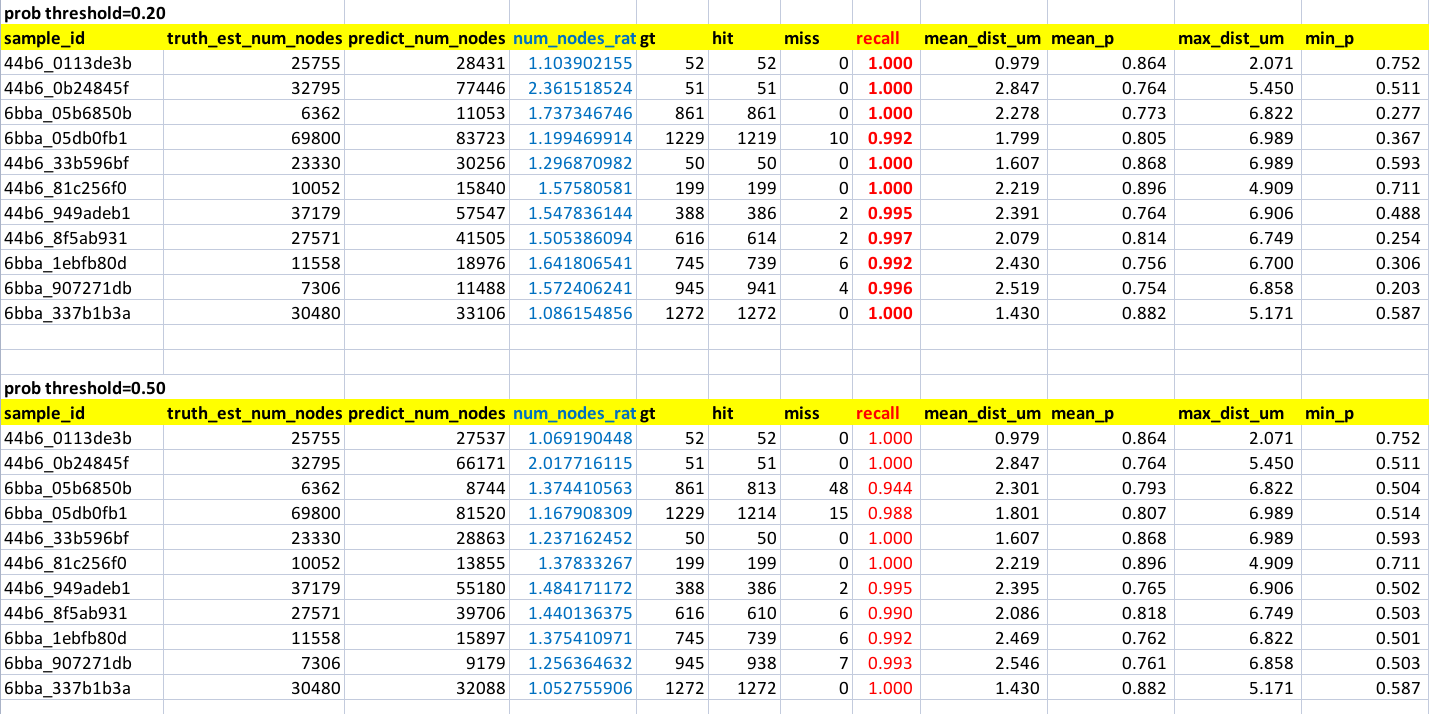

In [1]:
try:
    import zarr, geff, tracksdata

except: 
    import os
    import sys
    import subprocess
    import importlib
    import importlib.util
    from pathlib import Path
    
    # Polars wheel in the support package uses the 32-bit runtime package.
    os.environ.setdefault("POLARS_PREFER_PKG", "32")
    
    SUPPORT_DIR = Path(
        "/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1"
    )
    WHEELS_DIR = SUPPORT_DIR / "wheels"
    
    if not WHEELS_DIR.exists():
        # Fallback for Kaggle's shorter mounted dataset path.
        candidates = list(Path("/kaggle/input").glob("**/wheels"))
        if not candidates:
            raise FileNotFoundError("Could not find the attached offline wheels directory")
        WHEELS_DIR = candidates[0]
    
    print("Offline wheels:", WHEELS_DIR)
    
    
    # These are packages supplied by the attached dataset.
    # Deliberately exclude:
    #   numpy, scipy, torch, pandas, dask, xarray, numba, llvmlite
    #
    # Kaggle already supplies compatible versions of those packages.
    OFFLINE_PACKAGES = [
        "tracksdata",
        "zarr==3.2.1",
        "numcodecs==0.15.1",
        "donfig==0.8.1.post1",
        "geff==1.2.0.1.1",
        "geff-spec==1.1.1",
        "pyscipopt==6.2.1",
        "ilpy==0.6.0",
        "rustworkx==0.18.0",
        "polars==1.42.0",
        "polars-runtime-32==1.42.0",
        "bidict==0.23.1",
        "imagecodecs==2026.6.26",
    ]
    
    
    def module_missing(module_name: str) -> bool:
        return importlib.util.find_spec(module_name) is None
    
    
    # Import name differs from pip package name in several cases.
    REQUIRED_IMPORTS = {
        "tracksdata": "tracksdata",
        "zarr": "zarr",
        "numcodecs": "numcodecs",
        "geff": "geff",
        "pyscipopt": "pyscipopt",
        "ilpy": "ilpy",
        "rustworkx": "rustworkx",
        "polars": "polars",
        "imagecodecs": "imagecodecs",
    }
    
    
    def purge_modules(module_roots):
        """
        Remove already-imported package modules from sys.modules.
    
        Normally this cell runs before imports, but this also protects against
        accidental imports performed by earlier Kaggle initialization code.
        """
        for root in module_roots:
            for name in list(sys.modules):
                if name == root or name.startswith(root + "."):
                    sys.modules.pop(name, None)
    
    
    def install_offline_packages():
        cmd = [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-index",
            "--no-deps",
            "--find-links",
            str(WHEELS_DIR),
            *OFFLINE_PACKAGES,
        ]
    
        print("Installing attached packages without modifying NumPy/SciPy/Torch...")
        result = subprocess.run(
            cmd,
            text=True,
            capture_output=True,
        )
    
        if result.returncode != 0:
            print(result.stdout[-4000:])
            print(result.stderr[-4000:])
            raise RuntimeError("Offline dependency installation failed")
    
        purge_modules(REQUIRED_IMPORTS.values())
    
    
    install_offline_packages()
    
    
    # Verify the complete import chain needed by biohub_tracking.io.
    failures = {}
    
    for name, module_name in {
        **REQUIRED_IMPORTS,
        "numpy": "numpy",
        "scipy": "scipy",
        "dask": "dask.array",
        "xarray": "xarray",
    }.items():
        try:
            importlib.import_module(module_name)
        except Exception as exc:
            failures[name] = f"{type(exc).__name__}: {exc}"
    
    if failures:
        raise ImportError(
            "Dependency verification failed:\n"
            + "\n".join(f"{name}: {error}" for name, error in failures.items())
        )

import zarr, geff, tracksdata
print("All offline dependencies imported successfully.")

#-----------------------------------------------------------------------------------------
import sys
sys.path.append("/kaggle/input/datasets/hengck23/hengck23-cell-point-detector-demo")
sys.path.append("/kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/repo/src")
#import biohub_tracking as tracking_cellmot

import os
from dataclasses import asdict, dataclass
from pprint import pprint
import joblib
import numpy as np
from scipy.optimize import linear_sum_assignment
import torch

from geff import GeffMetadata
from biohub_tracking.io import open_dataset
import zarr
import tracksdata as td
import time

from model_v5 import StrongUNet3D3Level


print("import ok!!!")

Offline wheels: /kaggle/input/datasets/pilkwang/biohub-tracking-support-pack-50ep-v1/wheels
Installing attached packages without modifying NumPy/SciPy/Torch...


/usr/local/lib/python3.12/dist-packages/dask/array/image.py:7: FutureWarning: `find_available_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  from skimage.io import imread as sk_imread
/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `reset_plugins` is deprecated since version 0.25 and will be removed in version 0.27. The plugin infrastructure of `skimage.io` is deprecated. Instead, use `imageio` or other I/O packages directly.
  return _bootstrap._gcd_import(name[level:], package, level)


All offline dependencies imported successfully.
import ok!!!


In [2]:
#load model ----------------------------------------

DEVICE = "cuda:0"
CHECKPOINT =  f"/kaggle/input/datasets/hengck23/hengck23-cell-point-detector-demo/00000030.pth"

model = StrongUNet3D3Level(
    in_channels=1,
    channels=(64, 128, 256),
    node_channels=1,
    gradient_checkpointing=False,
).to(DEVICE)

ckp = torch.load( CHECKPOINT, map_location=DEVICE, weights_only=False,)
print( model.load_state_dict(ckp["model_state_dict"]))


#load daya ----------------------------------------
KAGGLE_DIR = "/kaggle/input/competitions/biohub-cell-tracking-during-development"

def load_one_for_infer(sample_id):
    zarr_file = f"{KAGGLE_DIR}/train/{sample_id}.zarr"
    geff_file = zarr_file.replace(".zarr", ".geff")

    ds = open_dataset(
        zarr_file,
        normalize=False,
        load_image=False,
        require_tracks=False,
    )
    q_low  = float(ds.quantiles["0.001"])
    q_high = float(ds.quantiles["0.999"])
    image = zarr.open_group(str(ds.zarr_path), mode="r")["0"]
    volume = image[:, ::1, ::4, ::4].astype(np.float32)
    volume = (volume - q_low) / (q_high - q_low + 1e-6)
    volume = np.clip(volume, 0.0, None).astype(np.float32)


    graph = td.graph.IndexedRXGraph.from_geff(geff_file)[0]
    node_df = graph.node_attrs().to_pandas()  # ['node_id', 't','z', 'y', 'x']
    tracks, lineage = td.functional.to_napari_format(
        graph,
        (100,64,256,256),  # image.shape,
        solution_key=None,
        output_tracklet_id_key="track_id",
        mask_key=None,
    )
    track_df = tracks.to_pandas() #[track_id,t,z,y,x]

    geff_meta = GeffMetadata.read(geff_file)
    est_num_nodes = float(geff_meta.extra["estimated_number_of_nodes"])
    meta = {
        "est_num_nodes": est_num_nodes,
        "downsample": [1, 4, 4],
        "um_per_voxel": [1.625, 1.625, 1.625],
    }
    return volume, meta, node_df, track_df


sample_id = "6bba_337b1b3a"
volume, meta, node_df, track_df = load_one_for_infer(sample_id)

#print(track_df)
#print(node_df)

##start inference here #####################################################

#helper  
def extract_node_peaks(
    node_logits,
    threshold,
    kernel_size,
):
    if kernel_size % 2 != 1:
        raise ValueError("node_peak_kernel must be odd")

    node_logits = node_logits.unsqueeze(1)
    prob = torch.sigmoid(node_logits.float())

    pooled = torch.nn.functional.max_pool3d(
        prob,
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size // 2,
    )

    keep = (prob >= pooled) & (prob >= float(threshold))

    B = len(prob)

    zyx = []
    p = []

    for b in range(B):
        # keep integer coordinates for indexing
        index_b = keep[b, 0].nonzero(as_tuple=False)  # (N,3), long

        p_b = prob[
            b,
            0,
            index_b[:, 0],
            index_b[:, 1],
            index_b[:, 2],
        ]
        zyx.append(index_b)
        p.append(p_b)

    return zyx, p

heatmap = []
node_tzyxp = []

start_time = time.time()
t_step=20
for t in range(0,100,t_step):
    print(f"t={t}")
    vol = volume[t:t+t_step]
    vol = torch.from_numpy(vol).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast("cuda", dtype=torch.float16 ):
            [f0, f1, f2], node_logits = model(vol)
            coord, prob = extract_node_peaks(
                node_logits,
                threshold=0.2,
                kernel_size=3,
            )
            heatmap.append(
                torch.sigmoid(node_logits.float()).detach().cpu().numpy()
            )

    # coord/prob are lists of length B
    B = len(coord)
    for b in range(B):
        zyx = coord[b]   # (N,3)
        p   = prob[b]    # (N,)

        if len(zyx) == 0:
            continue

        zyx = zyx.detach().cpu().numpy()
        p = p.detach().cpu().numpy()


        tb = np.full(
            (len(zyx), 1),
            t+b,
            dtype=np.float32,
        )
        tzyxp = np.concatenate(
            [
                tb,
                zyx.astype(np.float32),
                p[:, None].astype(np.float32),
            ],
            axis=1,
        )

        node_tzyxp.append(tzyxp)

if len(node_tzyxp) == 0:
    node_tzyxp = np.empty((0, 5), dtype=np.float32)
else:
    node_tzyxp = np.concatenate(node_tzyxp, axis=0)


elapsed = time.time() - start_time
heatmap = np.concatenate(heatmap, axis=0)
print(f"done!!! time = {elapsed} sec")
print(sample_id, meta, node_tzyxp.shape, heatmap.shape)


<All keys matched successfully>
t=0
t=20
t=40
t=60
t=80
done!!! time = 5.124085426330566 sec
6bba_337b1b3a {'est_num_nodes': 30480.0, 'downsample': [1, 4, 4], 'um_per_voxel': [1.625, 1.625, 1.625]} (32961, 5) (100, 64, 64, 64)


In [3]:
# do evaluation (eg recall of jaggle annotation), plot results
radius_um   = 7
p_threshold = 0.5

#select only those with prob > p_threshold
node_tzyxp= node_tzyxp[node_tzyxp[:,-1]>=p_threshold]

gt_scale = np.array(
    [1.625, 0.40625, 0.40625],
    dtype=np.float32,
)
pred_scale = np.array(
    [1.625, 1.625, 1.625],
    dtype=np.float32,
)

gt_zyx = node_df[["z", "y", "x"]].to_numpy(np.float32)
gt_zyx_um = gt_zyx * gt_scale[None, :]

pred_t      = node_tzyxp[:, 0].astype(np.int64)
pred_zyx    = node_tzyxp[:, 1:4]
pred_p      = node_tzyxp[:, 4]
pred_zyx_um = pred_zyx * pred_scale[None, :]

# --------------------------------------------------
# output arrays: one entry for every GT node

n_gt = len(node_df)
hit = np.zeros(n_gt, dtype=bool)
dist_um = np.full(n_gt, np.nan, dtype=np.float32)
matched_p = np.full(n_gt, np.nan, dtype=np.float32)
matched_pred_z = np.full(n_gt, np.nan, dtype=np.float32)
matched_pred_y = np.full(n_gt, np.nan, dtype=np.float32)
matched_pred_x = np.full(n_gt, np.nan, dtype=np.float32)


# start matching
unique_t = np.sort(node_df["t"].unique())
for t in unique_t:
    gt_idx = np.where(
        node_df["t"].to_numpy() == t
    )[0]
    pred_idx = np.where(
        pred_t == int(t)
    )[0]

    # No predictions at this t. all GT remain misses.
    if len(pred_idx) == 0:
        continue

    g = gt_zyx_um[gt_idx]
    p = pred_zyx_um[pred_idx]

    # pairwise distance in micron
    d = np.linalg.norm( g[:, None, :] - p[None, :, :], axis=-1 )
    row, col = linear_sum_assignment(d)

    for r, c in zip(row, col):
        gi = gt_idx[r]
        pi = pred_idx[c]
        distance = float(d[r, c])

        # Record assignment distance/p even if > radius.
        dist_um[gi]   = distance
        matched_p[gi] = pred_p[pi]
        matched_pred_z[gi] = pred_zyx[pi, 0]
        matched_pred_y[gi] = pred_zyx[pi, 1]
        matched_pred_x[gi] = pred_zyx[pi, 2]
        if distance <= radius_um:
            hit[gi] = True


# --------------------------------------------------
# summary of evaluation
# --------------------------------------------------

num_hit = int(hit.sum())
num_gt = len(hit)

summary = {
    "sample_id": sample_id,
    "truth_est_num_nodes": meta["est_num_nodes"],
    "predict_num_nodes": len(node_tzyxp),
    "num_nodes_ratio": len(node_tzyxp)/meta["est_num_nodes"],
    "gt":  num_gt,
    "hit": num_hit,
    "miss": num_gt - num_hit,
    "recall": num_hit / max(num_gt, 1),
    "mean_dist_um": (
        float(np.nanmean(dist_um[hit]))
        if num_hit > 0
        else np.nan
    ),
    "mean_p": (
        float(np.nanmean(matched_p[hit]))
        if num_hit > 0
        else np.nan
    ),

    "max_dist_um": (
        float(np.max(dist_um[hit]))
        if num_hit > 0
        else np.nan
    ),
    "min_p": (
        float(np.min(matched_p[hit]))
        if num_hit > 0
        else np.nan
    ),
}
pprint(summary)

{'gt': 1272,
 'hit': 1272,
 'max_dist_um': 5.170718193054199,
 'mean_dist_um': 1.4338843822479248,
 'mean_p': 0.880255937576294,
 'min_p': 0.5672175884246826,
 'miss': 0,
 'num_nodes_ratio': 1.0476377952755906,
 'predict_num_nodes': 31932,
 'recall': 1.0,
 'sample_id': '6bba_337b1b3a',
 'truth_est_num_nodes': 30480.0}


In [4]:
import plotly.graph_objects as go

l = 64
X, Y, Z = np.mgrid[:l, :l, :l]

if 0: #enable to plot heatmap 3d
    fig = go.Figure(data=go.Volume(
        x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
        value=heatmap[50].flatten(),
        isomin=0.2,
        isomax=0.7,
        opacity=0.1,
        surface_count=25,
        ))
    fig.update_layout(scene_xaxis_showticklabels=False,
                      scene_yaxis_showticklabels=False,
                      scene_zaxis_showticklabels=False)
    fig.show()

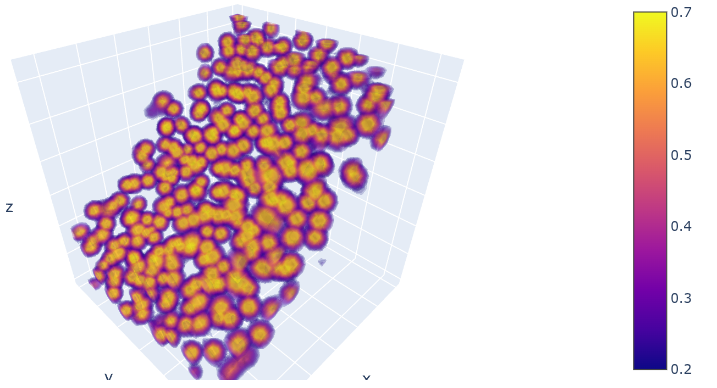
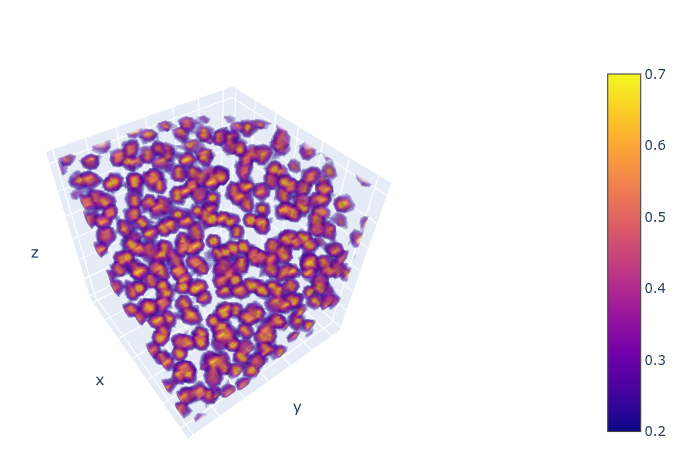

In [5]:
### import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure() 
colors = px.colors.qualitative.Plotly

'''
Edge Jaccard: Predicted nodes are matched to ground-truth nodes per timepoint via optimal bipartite assignment
on scaled centroid distance (max 7.0 µm, physical scale z=1.625, y=x=0.40625 µm/voxel).
'''
def add_sphere(fig, x0, y0, z0, r=7.0, color="red", opacity=0.08, n=16):
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)

    x = x0 + r * np.outer(np.cos(u), np.sin(v))
    y = y0 + r * np.outer(np.sin(u), np.sin(v))
    z = z0 + r * np.outer(np.ones_like(u), np.cos(v))

    fig.add_trace(
        go.Surface(
            x=x,
            y=y,
            z=z,
            showscale=False,
            opacity=opacity,
            surfacecolor=np.zeros_like(x),
            colorscale=[[0, color], [1, color]],
            hoverinfo="skip",
        )
    )
    
#[1.625, 0.40625, 0.40625],
if 0: #uncomment to plot
    for i, (track_id, g) in enumerate(track_df.groupby("track_id")):
        color = colors[i % len(colors)]
     
        z = g["z"].to_numpy() * 1.625
        y = g["y"].to_numpy() * 0.40625
        x = g["x"].to_numpy() * 0.40625
    
        fig.add_trace(
            go.Scatter3d(
                x=x,
                y=y,
                z=z,
                mode="lines+markers",
                name=str(track_id),
                line=dict(width=4, color=color),
                marker=dict(size=4, color=color),
                text=[
                    f"track_id={track_id}<br>t={t}<br>(z,y,x)=({zz:.1f},{yy:.1f},{xx:.1f})"
                    for t, zz, yy, xx in zip(g["t"], g["z"], g["y"], g["x"])
                ],
                hoverinfo="text",
            )
        )
    
        if track_id==1:
            # add error limit 7 um sphere around each GT point
            for x0, y0, z0 in zip(x, y, z):
                add_sphere(fig, x0, y0, z0, r=3.5, color=color, opacity=0.02, n=12)
    
    #-------
    tz = node_df["z"].to_numpy() * 1.625
    ty = node_df["y"].to_numpy() * 0.40625
    tx = node_df["x"].to_numpy() * 0.40625
        
    z=matched_pred_z*1.625
    y=matched_pred_y*1.625
    x=matched_pred_x*1.625 
    
    line_x = []
    line_y = []
    line_z = []
    for i in range(len(x)):
        line_x.extend([x[i], tx[i], None])
        line_y.extend([y[i], ty[i], None])
        line_z.extend([z[i], tz[i], None])
    
    fig.add_trace( 
        go.Scatter3d( 
            x=x,
            y=y,
            z=z,          
            mode="markers",
            
            marker=dict(
                size=4,
                color="red",
            ),
        )
    )
    
    
    fig.add_trace(
        go.Scatter3d(
            x=line_x,
            y=line_y,
            z=line_z,
            mode="lines",
            line=dict(
                color="red",
                width=1, 
            ),
            opacity=0.5,
            hoverinfo="skip",
            showlegend=False,
        )
    )
    
    
    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        width=1000,
        height=600,
        showlegend=False,
    )
    
    fig.show()

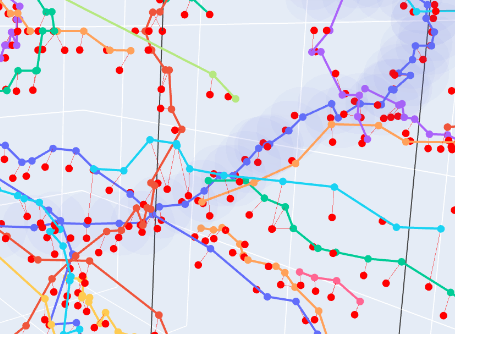